<a href="https://colab.research.google.com/github/AlejoCNYT/Curso_CENDES/blob/main/redes_neuronales_uci.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# @title Celda 0 — Instalacion e Imports
!pip install ucimlrepo -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             r2_score, mean_absolute_error, mean_squared_error)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from ucimlrepo import fetch_ucirepo

torch.manual_seed(42)
np.random.seed(42)

plt.style.use("seaborn-v0_8-whitegrid")
print("Imports completados correctamente")
print(f"PyTorch version: {torch.__version__}")


Imports completados correctamente
PyTorch version: 2.10.0+cu128


# Analisis Exploratorio de Datos (EDA)

Antes de construir modelos es fundamental entender los datos.
El dataset **Wine Quality** (UCI ML Repository) contiene características
fisicoquímicas de vinos y una puntuación de calidad (0–10).

- **11 features numéricas**: acidez, sulfatos, alcohol, pH, etc.
- **Target para clasificación**: binario (calidad ≥ 6 → bueno=1, < 6 → malo=0)
- **Target para regresión**: score continuo (0–10)


In [26]:
# @title EDA — Carga del Dataset
# Descarga del dataset
wine_quality = fetch_ucirepo(id=186)
X_df = wine_quality.data.features
y_df = wine_quality.data.targets

print("Shape features:", X_df.shape)
print("Shape targets: ", y_df.shape)
print("\nColumnas:", list(X_df.columns))
print("\nTipos de datos:")
print(X_df.dtypes)


Shape features: (6497, 11)
Shape targets:  (6497, 1)

Columnas: ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Tipos de datos:
fixed_acidity           float64
volatile_acidity        float64
citric_acid             float64
residual_sugar          float64
chlorides               float64
free_sulfur_dioxide     float64
total_sulfur_dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
dtype: object


In [27]:
# Estadísticas descriptivas
print("=== Estadísticas Descriptivas ===")
display(X_df.describe().round(3))


=== Estadísticas Descriptivas ===


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900


In [28]:
# Preparación de targets
y_reg = y_df.values.flatten().astype(np.float32)   # score continuo (regresión)
y_clf = (y_reg >= 6).astype(np.float32)             # binario (clasificación)

X_np = X_df.values.astype(np.float32)
n_features = X_np.shape[1]
feature_names = list(X_df.columns)

print(f"Regresión — min: {y_reg.min():.1f}  max: {y_reg.max():.1f}  media: {y_reg.mean():.2f}")
print(f"Clasificación — Malo(0): {(y_clf==0).sum()}  Bueno(1): {(y_clf==1).sum()}")
print(f"Proporción positiva: {y_clf.mean():.2%}")


Regresión — min: 3.0  max: 9.0  media: 5.82
Clasificación — Malo(0): 2384  Bueno(1): 4113
Proporción positiva: 63.31%


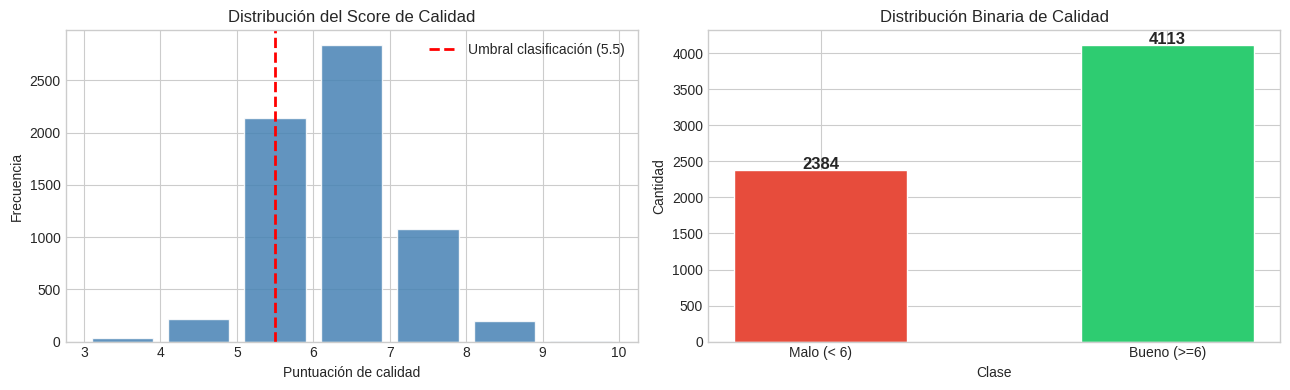

In [29]:
# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(y_reg, bins=range(3, 11), color="steelblue",
             edgecolor="white", alpha=0.85, rwidth=0.8)
axes[0].axvline(x=5.5, color="red", linestyle="--", lw=2,
                label="Umbral clasificación (5.5)")
axes[0].set_xlabel("Puntuación de calidad")
axes[0].set_ylabel("Frecuencia")
axes[0].set_title("Distribución del Score de Calidad")
axes[0].legend()

conteos = [(y_clf == 0).sum(), (y_clf == 1).sum()]
bars = axes[1].bar(["Malo (< 6)", "Bueno (>=6)"], conteos,
                   color=["#e74c3c", "#2ecc71"], edgecolor="white", width=0.5)
for bar, cnt in zip(bars, conteos):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
                 str(cnt), ha="center", fontweight="bold", fontsize=12)
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("Cantidad")
axes[1].set_title("Distribución Binaria de Calidad")

plt.tight_layout()
plt.show()


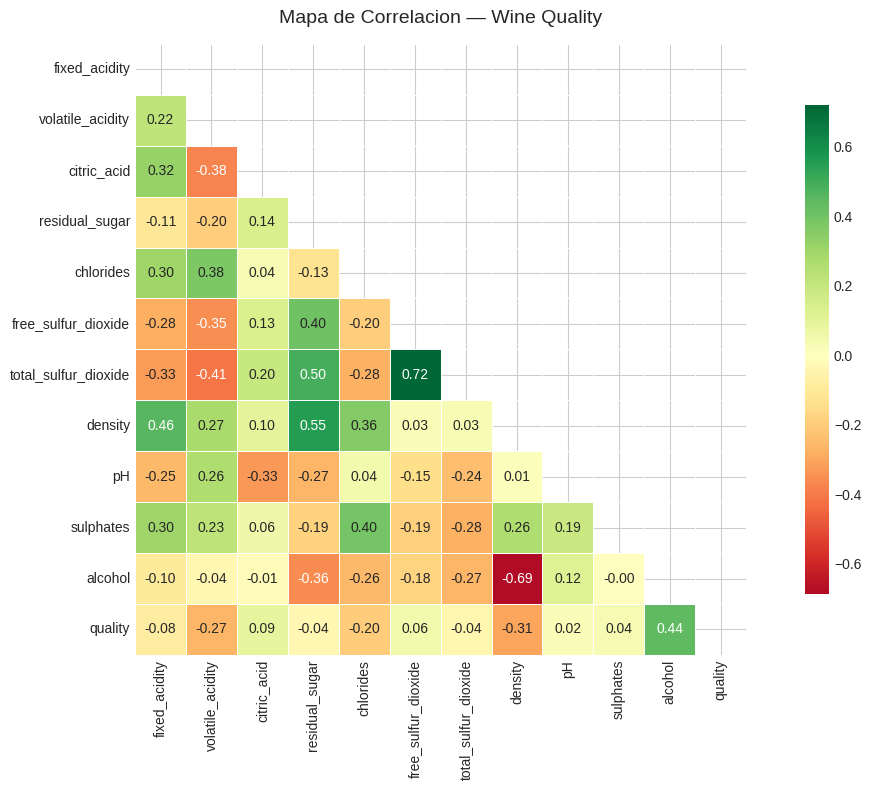

Top features por correlacion con quality:
alcohol             0.444319
density             0.305858
volatile_acidity    0.265699
chlorides           0.200666
citric_acid         0.085532
fixed_acidity       0.076743


In [30]:
# Heatmap de correlación
corr_df = X_df.copy()
corr_df["quality"] = y_reg
corr = corr_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            mask=mask, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Mapa de Correlacion — Wine Quality", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Top features por correlación con quality
corr_q = corr_df.corr()["quality"].drop("quality").abs().sort_values(ascending=False)
print("Top features por correlacion con quality:")
print(corr_q.head(6).to_string())


/tmp/ipykernel_8718/4136166855.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_malo, data_bueno],
/tmp/ipykernel_8718/4136166855.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_malo, data_bueno],
/tmp/ipykernel_8718/4136166855.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_malo, data_bueno],
/tmp/ipykernel_8718/4136166855.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data

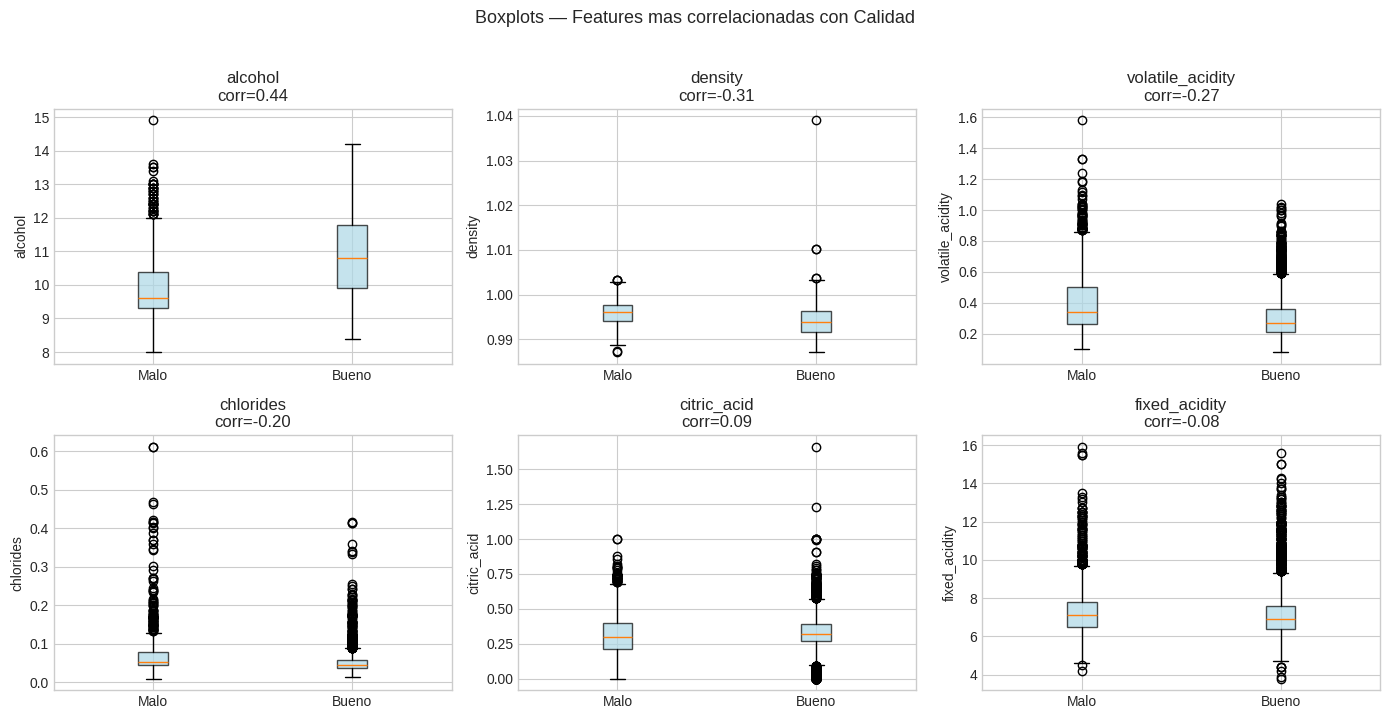

In [31]:
# Boxplots de las 6 features más correlacionadas con quality
corr_df2 = X_df.copy()
corr_df2["quality"] = y_reg
top6 = corr_df2.corr()["quality"].drop("quality").abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, feat in enumerate(top6):
    data_malo   = X_df.loc[y_clf == 0, feat]
    data_bueno  = X_df.loc[y_clf == 1, feat]
    bp = axes[i].boxplot([data_malo, data_bueno],
                         labels=["Malo", "Bueno"], patch_artist=True,
                         boxprops=dict(facecolor="lightblue", alpha=0.7))
    corr_val = corr_df2.corr()["quality"][feat]
    axes[i].set_title(f"{feat}\ncorr={corr_val:.2f}")
    axes[i].set_ylabel(feat)

plt.suptitle("Boxplots — Features mas correlacionadas con Calidad", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
# FASE 1 — Fundamentos Matematicos (NumPy puro)

## Objetivo Pedagogico

Construimos una red neuronal **completamente desde cero** usando solo NumPy.
El objetivo es entender cada operacion matematica:

1. **Funciones de activacion**: transforman la suma ponderada en la salida de una neurona.
2. **Forward pass**: calcula la prediccion capa por capa.
3. **Funcion de perdida**: mide el error entre prediccion y valor real.
4. **Backpropagation**: calcula gradientes usando la regla de la cadena.
5. **Descenso del gradiente**: actualiza pesos en la dirección que minimiza el error.

Esta implementacion manual permite entender exactamente **que hacen** PyTorch y TensorFlow internamente.


## 1.1 Funciones de Activacion

### Sigmoide
$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \sigma'(z) = \sigma(z)\bigl(1 - \sigma(z)\bigr)$$

Mapea cualquier valor real al intervalo $(0,1)$. Ideal para clasificacion binaria en la capa de salida.

### ReLU (Rectified Linear Unit)
$$\text{ReLU}(z) = \max(0, z), \qquad \text{ReLU}'(z) = \begin{cases} 1 & z > 0 \\ 0 & z \leq 0 \end{cases}$$

Mitiga el problema del gradiente evanescente en capas ocultas.

### Softmax
$$\text{softmax}(z_i) = \frac{e^{z_i - \max z}}{\sum_j e^{z_j - \max z}}$$

Convierte un vector de scores en distribucion de probabilidad (clasificacion multiclase).


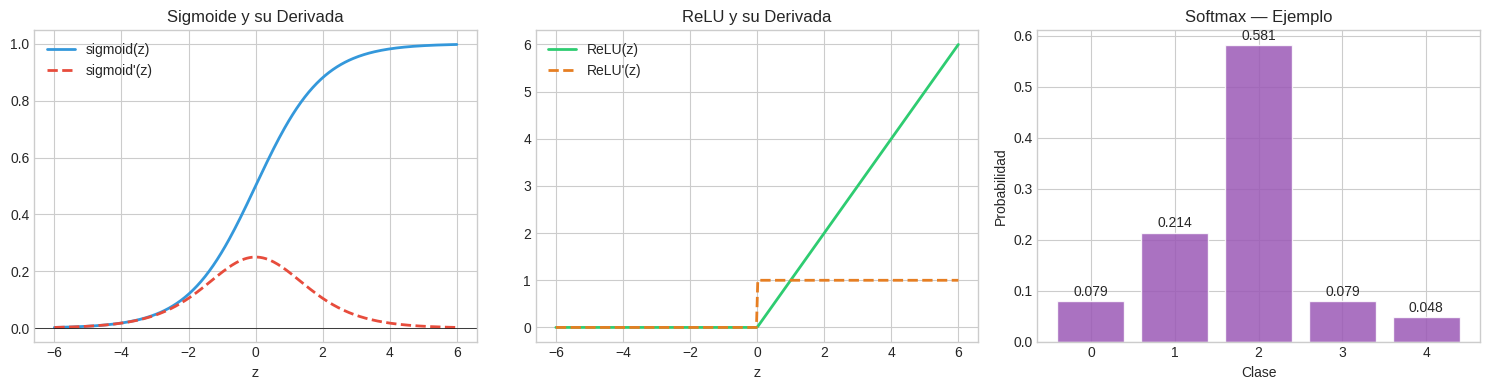

In [32]:
# @title Fase 1 — Funciones de Activacion
def sigmoid(z):
    """Funcion sigmoide: mapea R -> (0, 1)."""
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

def sigmoid_deriv(z):
    """Derivada de la sigmoide: sigma(z) * (1 - sigma(z))."""
    s = sigmoid(z)
    return s * (1 - s)

def relu(z):
    """ReLU: max(0, z)."""
    return np.maximum(0, z)

def relu_deriv(z):
    """Derivada de ReLU: indicadora z > 0."""
    return (z > 0).astype(np.float32)

def softmax(z):
    """Softmax numericamente estable."""
    z_s = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z_s)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Visualizacion
z_vals = np.linspace(-6, 6, 300)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(z_vals, sigmoid(z_vals), color="#3498db", lw=2, label="sigmoid(z)")
axes[0].plot(z_vals, sigmoid_deriv(z_vals), color="#e74c3c", lw=2,
             linestyle="--", label="sigmoid'(z)")
axes[0].set_title("Sigmoide y su Derivada")
axes[0].set_xlabel("z")
axes[0].legend()
axes[0].axhline(0, color="black", lw=0.5)

axes[1].plot(z_vals, relu(z_vals), color="#2ecc71", lw=2, label="ReLU(z)")
axes[1].plot(z_vals, relu_deriv(z_vals), color="#e67e22", lw=2,
             linestyle="--", label="ReLU'(z)")
axes[1].set_title("ReLU y su Derivada")
axes[1].set_xlabel("z")
axes[1].legend()

z_ex = np.array([[1.0, 2.0, 3.0, 1.0, 0.5]])
probs = softmax(z_ex)[0]
axes[2].bar(range(len(probs)), probs, color="#9b59b6", edgecolor="white", alpha=0.85)
axes[2].set_title("Softmax — Ejemplo")
axes[2].set_xlabel("Clase")
axes[2].set_ylabel("Probabilidad")
for i, p in enumerate(probs):
    axes[2].text(i, p + 0.01, f"{p:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()


## 1.2 Red MLP desde cero

### Forward Pass
Para una red con $L$ capas:
$$z^{[l]} = a^{[l-1]} W^{[l]} + b^{[l]}, \qquad a^{[l]} = g^{[l]}(z^{[l]})$$

### BCE Loss (Binary Cross-Entropy)
$$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \bigl[ y_i \log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i) \bigr]$$

### Backpropagation
$$\frac{\partial \mathcal{L}}{\partial W^{[l]}} = \frac{1}{m} (a^{[l-1]})^\top \cdot \delta^{[l]}, \qquad \delta^{[l]} = \delta^{[l+1]} (W^{[l+1]})^\top \odot g'^{[l]}(z^{[l]})$$

Para la capa de salida con BCE + Sigmoid el gradiente combinado simplifica a:
$$\delta^{[L]} = \frac{\hat{y} - y}{m}$$

### Inicializacion Xavier/Glorot
$$W \sim \mathcal{N}\!\left(0,\; \sqrt{\frac{2}{n_{\text{in}} + n_{\text{out}}}}\right)$$


In [33]:
# @title Fase 1 — Clase MLPNumpy
class MLPNumpy:
    """Red neuronal MLP implementada desde cero con NumPy puro.

    Capas ocultas con ReLU, capa de salida con Sigmoid.
    Optimizacion por descenso del gradiente (SGD).
    """

    def __init__(self, layer_sizes):
        """Inicializa pesos con Xavier y biases en cero.

        Args:
            layer_sizes: lista con neuronas por capa, ej. [11, 64, 32, 1]
        """
        self.layer_sizes = layer_sizes
        self.n_layers = len(layer_sizes) - 1
        self.W = []
        self.b = []
        for i in range(self.n_layers):
            fan_in, fan_out = layer_sizes[i], layer_sizes[i + 1]
            escala = np.sqrt(2.0 / (fan_in + fan_out))
            self.W.append(np.random.randn(fan_in, fan_out).astype(np.float32) * escala)
            self.b.append(np.zeros((1, fan_out), dtype=np.float32))
        self.activaciones = []
        self.z_vals = []
        self.grad_W = [None] * self.n_layers
        self.grad_b = [None] * self.n_layers

    def forward(self, X):
        """Propagacion hacia adelante; guarda activaciones para backprop.

        Args:
            X: array (batch, n_features)
        Returns:
            Predicciones (batch, 1) en rango (0, 1)
        """
        self.activaciones = [X]
        self.z_vals = []
        a = X
        for i in range(self.n_layers):
            z = a @ self.W[i] + self.b[i]
            self.z_vals.append(z)
            a = relu(z) if i < self.n_layers - 1 else sigmoid(z)
            self.activaciones.append(a)
        return self.activaciones[-1]

    def compute_loss(self, y_pred, y_true):
        """BCE loss numericamente estable.

        Args:
            y_pred: predicciones (batch, 1)
            y_true: etiquetas (batch, 1)
        Returns:
            Escalar con el valor de la perdida
        """
        eps = 1e-8
        y_p = np.clip(y_pred, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(y_p) + (1 - y_true) * np.log(1 - y_p))

    def backward(self, X, y_true):
        """Backpropagation: calcula gradientes por la regla de la cadena.

        Args:
            X: features de entrenamiento (batch, n_features)
            y_true: etiquetas reales (batch, 1)
        """
        m = X.shape[0]
        # Gradiente combinado BCE + Sigmoid: simplifica a (y_pred - y) / m
        delta = (self.activaciones[-1] - y_true) / m
        for i in range(self.n_layers - 1, -1, -1):
            a_prev = self.activaciones[i]
            self.grad_W[i] = a_prev.T @ delta
            self.grad_b[i] = np.sum(delta, axis=0, keepdims=True)
            if i > 0:
                delta = (delta @ self.W[i].T) * relu_deriv(self.z_vals[i - 1])

    def update_weights(self, lr):
        """Actualiza pesos con descenso del gradiente.

        Args:
            lr: tasa de aprendizaje
        """
        for i in range(self.n_layers):
            self.W[i] -= lr * self.grad_W[i]
            self.b[i] -= lr * self.grad_b[i]

    def predict(self, X):
        """Prediccion binaria (threshold=0.5)."""
        return (self.forward(X) >= 0.5).astype(np.float32)

    def accuracy(self, X, y):
        """Exactitud de clasificacion."""
        return float(np.mean(self.predict(X) == y))


print("Clase MLPNumpy definida correctamente.")


Clase MLPNumpy definida correctamente.


In [34]:
# Preparacion de datos para Fase 1
indices = np.arange(len(X_np))
idx_temp, idx_test_f1 = train_test_split(
    indices, test_size=0.20, random_state=42, stratify=y_clf)
idx_train_f1, idx_val_f1 = train_test_split(
    idx_temp, test_size=0.125, random_state=42, stratify=y_clf[idx_temp])

X_train_f1 = X_np[idx_train_f1]
X_val_f1   = X_np[idx_val_f1]
X_test_f1  = X_np[idx_test_f1]
y_train_f1 = y_clf[idx_train_f1].reshape(-1, 1)
y_val_f1   = y_clf[idx_val_f1].reshape(-1, 1)
y_test_f1  = y_clf[idx_test_f1].reshape(-1, 1)

scaler_f1 = StandardScaler()
X_train_f1 = scaler_f1.fit_transform(X_train_f1).astype(np.float32)
X_val_f1   = scaler_f1.transform(X_val_f1).astype(np.float32)
X_test_f1  = scaler_f1.transform(X_test_f1).astype(np.float32)

print(f"Train: {X_train_f1.shape}  Val: {X_val_f1.shape}  Test: {X_test_f1.shape}")


Train: (4547, 11)  Val: (650, 11)  Test: (1300, 11)


In [35]:
# @title Fase 1 — Entrenamiento MLPNumpy
# Hiperparametros Fase 1
ARQUITECTURA_NP = [n_features, 64, 32, 1]
EPOCAS_NP = 200
LR_NP = 0.05

# Guardamos pesos iniciales para visualización posterior
mlp_np = MLPNumpy(ARQUITECTURA_NP)
pesos_iniciales_W1 = mlp_np.W[0].copy()

# Loop de entrenamiento
hist_loss_np = []
hist_acc_np  = []

for epoca in range(EPOCAS_NP):
    y_pred = mlp_np.forward(X_train_f1)
    loss   = mlp_np.compute_loss(y_pred, y_train_f1)
    mlp_np.backward(X_train_f1, y_train_f1)
    mlp_np.update_weights(LR_NP)
    hist_loss_np.append(loss)
    hist_acc_np.append(mlp_np.accuracy(X_train_f1, y_train_f1))

    if (epoca + 1) % 50 == 0:
        val_acc = mlp_np.accuracy(X_val_f1, y_val_f1)
        print(f"Epoca {epoca+1:3d}/{EPOCAS_NP} | Loss: {loss:.4f} | "
              f"Train Acc: {hist_acc_np[-1]:.4f} | Val Acc: {val_acc:.4f}")

test_acc_np = mlp_np.accuracy(X_test_f1, y_test_f1)
print(f"\nAccuracy en test: {test_acc_np:.4f}")


Epoca  50/200 | Loss: 0.6174 | Train Acc: 0.6527 | Val Acc: 0.6400
Epoca 100/200 | Loss: 0.5688 | Train Acc: 0.7117 | Val Acc: 0.6738
Epoca 150/200 | Loss: 0.5402 | Train Acc: 0.7297 | Val Acc: 0.7092
Epoca 200/200 | Loss: 0.5246 | Train Acc: 0.7367 | Val Acc: 0.7246

Accuracy en test: 0.7292


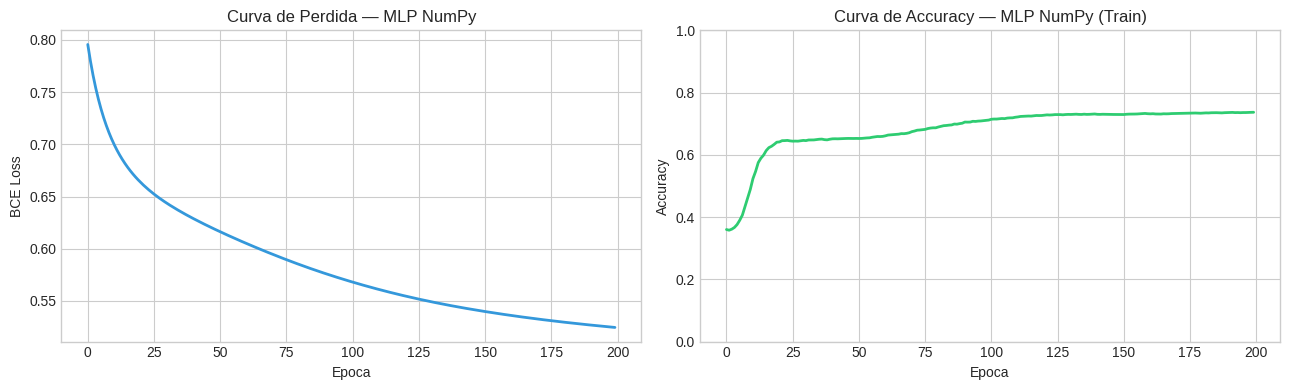

In [36]:
# Curvas de entrenamiento NumPy
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_loss_np, color="#3498db", lw=2)
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Curva de Perdida — MLP NumPy")

axes[1].plot(hist_acc_np, color="#2ecc71", lw=2)
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Curva de Accuracy — MLP NumPy (Train)")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


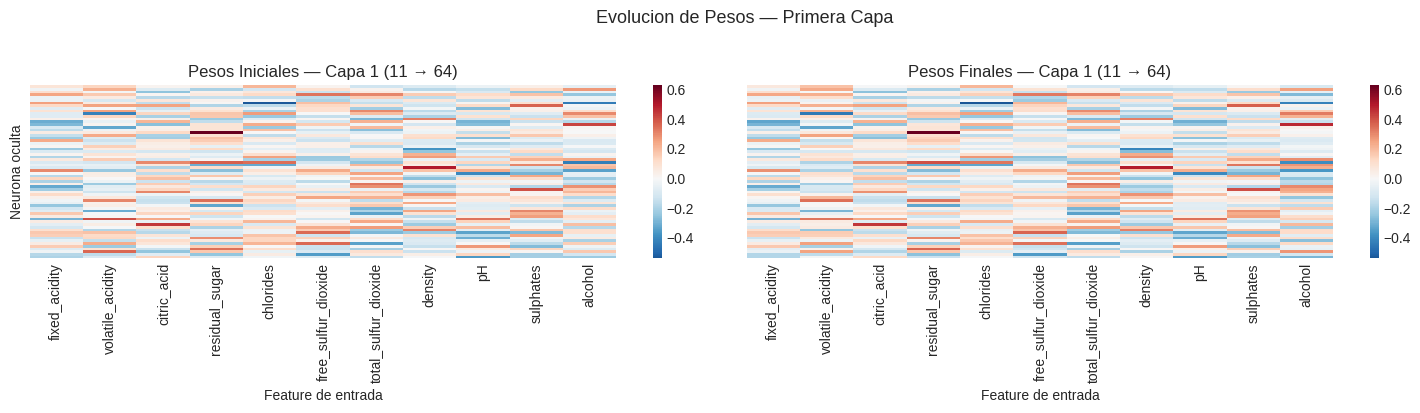

In [37]:
# Visualizacion de pesos: iniciales vs finales
pesos_finales_W1 = mlp_np.W[0].copy()

vmin = min(pesos_iniciales_W1.min(), pesos_finales_W1.min())
vmax = max(pesos_iniciales_W1.max(), pesos_finales_W1.max())

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.heatmap(pesos_iniciales_W1.T, ax=axes[0], cmap="RdBu_r", center=0,
            vmin=vmin, vmax=vmax,
            xticklabels=feature_names, yticklabels=False)
axes[0].set_title("Pesos Iniciales — Capa 1 (11 → 64)")
axes[0].set_xlabel("Feature de entrada")
axes[0].set_ylabel("Neurona oculta")

sns.heatmap(pesos_finales_W1.T, ax=axes[1], cmap="RdBu_r", center=0,
            vmin=vmin, vmax=vmax,
            xticklabels=feature_names, yticklabels=False)
axes[1].set_title("Pesos Finales — Capa 1 (11 → 64)")
axes[1].set_xlabel("Feature de entrada")

plt.suptitle("Evolucion de Pesos — Primera Capa", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
# FASE 2 — Red Fully Connected con PyTorch

## Objetivo Pedagogico

Usamos **PyTorch** para construir las mismas redes que en la Fase 1,
aprovechando las abstracciones del framework:

- **Dataset / DataLoader**: manejo eficiente de datos en mini-batches.
- **nn.Module**: construccion declarativa de arquitecturas.
- **Autograd**: diferenciacion automatica (no calculamos gradientes a mano).
- **Optimizers**: Adam y variantes con ajuste adaptativo del learning rate.
- **Regularizacion**: Dropout y Batch Normalization integrados.

La ventaja clave es que PyTorch calcula los gradientes automaticamente mediante
el grafo computacional dinamico.


In [38]:
# @title Fase 2 — Dataset y DataLoaders
class WineDataset(Dataset):
    """Dataset de PyTorch para Wine Quality.

    Args:
        X: matriz de features (numpy array)
        y: vector de targets (numpy array)
    """

    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.FloatTensor(y)

    def __len__(self):
        """Numero de muestras."""
        return len(self.X)

    def __getitem__(self, idx):
        """Par (features, target) por indice."""
        return self.X[idx], self.y[idx]


# Hiperparametros de particion
PROP_TRAIN = 0.70
PROP_VAL   = 0.15
PROP_TEST  = 0.15
BATCH_SIZE = 32

# Split con indices compartidos para clf y reg
indices_pt = np.arange(len(X_np))
idx_temp_pt, idx_test_pt = train_test_split(
    indices_pt, test_size=PROP_TEST, random_state=42, stratify=y_clf)
idx_train_pt, idx_val_pt = train_test_split(
    idx_temp_pt, test_size=PROP_VAL / (PROP_TRAIN + PROP_VAL),
    random_state=42, stratify=y_clf[idx_temp_pt])

X_train_pt = X_np[idx_train_pt]
X_val_pt   = X_np[idx_val_pt]
X_test_pt  = X_np[idx_test_pt]

# Normalizacion
scaler_pt = StandardScaler()
X_train_sc = scaler_pt.fit_transform(X_train_pt).astype(np.float32)
X_val_sc   = scaler_pt.transform(X_val_pt).astype(np.float32)
X_test_sc  = scaler_pt.transform(X_test_pt).astype(np.float32)

# Targets clasificacion
y_clf_train = y_clf[idx_train_pt]
y_clf_val   = y_clf[idx_val_pt]
y_clf_test  = y_clf[idx_test_pt]

# Targets regresion
y_reg_train = y_reg[idx_train_pt]
y_reg_val   = y_reg[idx_val_pt]
y_reg_test  = y_reg[idx_test_pt]

# DataLoaders clasificacion
train_ds_clf = WineDataset(X_train_sc, y_clf_train)
val_ds_clf   = WineDataset(X_val_sc,   y_clf_val)
test_ds_clf  = WineDataset(X_test_sc,  y_clf_test)
train_dl_clf = DataLoader(train_ds_clf, batch_size=BATCH_SIZE, shuffle=True)
val_dl_clf   = DataLoader(val_ds_clf,   batch_size=BATCH_SIZE)
test_dl_clf  = DataLoader(test_ds_clf,  batch_size=BATCH_SIZE)

# DataLoaders regresion
train_ds_reg = WineDataset(X_train_sc, y_reg_train)
val_ds_reg   = WineDataset(X_val_sc,   y_reg_val)
test_ds_reg  = WineDataset(X_test_sc,  y_reg_test)
train_dl_reg = DataLoader(train_ds_reg, batch_size=BATCH_SIZE, shuffle=True)
val_dl_reg   = DataLoader(val_ds_reg,   batch_size=BATCH_SIZE)
test_dl_reg  = DataLoader(test_ds_reg,  batch_size=BATCH_SIZE)

print(f"Train: {len(train_ds_clf)}  Val: {len(val_ds_clf)}  Test: {len(test_ds_clf)}")


Train: 4547  Val: 975  Test: 975


## 2.1 Clasificacion Binaria con PyTorch

Arquitectura:

$$\text{Input}(11) \to \underbrace{\text{Linear}(64) \to \text{ReLU} \to \text{Dropout}(0.3)}_{\text{capa oculta 1}} \to \underbrace{\text{Linear}(32) \to \text{ReLU}}_{\text{capa oculta 2}} \to \text{Linear}(1) \to \sigma$$

- **Loss**: BCE — $\mathcal{L}_{BCE}$
- **Optimizer**: Adam con $\alpha = 0.001$
- **Early Stopping**: parar si `val_loss` no mejora en 15 epocas


In [15]:
# @title Fase 2 — MLPClasificador
class MLPClasificador(nn.Module):
    """MLP para clasificacion binaria del vino.

    Arquitectura: Linear(11->64) -> ReLU -> Dropout
                  -> Linear(64->32) -> ReLU -> Linear(32->1) -> Sigmoid
    """

    def __init__(self, p_dropout=0.3):
        """
        Args:
            p_dropout: probabilidad de dropout (default 0.3)
        """
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            nn.Dropout(p_dropout),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        """Propagacion hacia adelante."""
        return self.red(x)


def entrenar_clasificador(modelo, train_dl, val_dl,
                          n_epocas=150, lr=0.001, paciencia=15,
                          peso_decay=0.0, verbose=True):
    """Entrena un MLPClasificador con early stopping.

    Args:
        modelo: instancia de MLPClasificador
        train_dl, val_dl: DataLoaders de train y validacion
        n_epocas: epocas maximas de entrenamiento
        lr: learning rate del optimizador Adam
        paciencia: epocas sin mejora antes de detener
        peso_decay: coeficiente L2 (weight_decay en Adam)
        verbose: mostrar progreso
    Returns:
        dict con listas loss_train, loss_val, acc_val
    """
    criterio  = nn.BCELoss()
    optimizer = optim.Adam(modelo.parameters(), lr=lr, weight_decay=peso_decay)

    mejor_val_loss    = float("inf")
    contador_paciencia = 0
    mejor_estado      = None

    hist = {"loss_train": [], "loss_val": [], "acc_val": []}
    X_val_t = val_dl.dataset.X
    y_val_t = val_dl.dataset.y.unsqueeze(1)

    for epoca in range(n_epocas):
        modelo.train()
        loss_total = 0.0
        for X_b, y_b in train_dl:
            y_b = y_b.unsqueeze(1)
            optimizer.zero_grad()
            loss = criterio(modelo(X_b), y_b)
            loss.backward()
            optimizer.step()
            loss_total += loss.item()

        modelo.eval()
        with torch.no_grad():
            pred_val = modelo(X_val_t)
            loss_val = criterio(pred_val, y_val_t).item()
            acc_val  = ((pred_val >= 0.5).float() == y_val_t).float().mean().item()

        hist["loss_train"].append(loss_total / len(train_dl))
        hist["loss_val"].append(loss_val)
        hist["acc_val"].append(acc_val)

        if loss_val < mejor_val_loss:
            mejor_val_loss     = loss_val
            contador_paciencia = 0
            mejor_estado       = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            contador_paciencia += 1
            if contador_paciencia >= paciencia:
                if verbose:
                    print(f"  Early stopping en epoca {epoca+1}  "
                          f"(mejor val_loss={mejor_val_loss:.4f})")
                break

        if verbose and (epoca + 1) % 30 == 0:
            print(f"  Epoca {epoca+1:3d} | loss_train={hist['loss_train'][-1]:.4f} "
                  f"| loss_val={loss_val:.4f} | acc_val={acc_val:.4f}")

    if mejor_estado:
        modelo.load_state_dict(mejor_estado)
    return hist


print("Entrenando MLPClasificador...")
clf_modelo = MLPClasificador(p_dropout=0.3)
hist_clf   = entrenar_clasificador(clf_modelo, train_dl_clf, val_dl_clf,
                                   n_epocas=150, paciencia=15)
print("Entrenamiento completado.")


Entrenando MLPClasificador...
  Epoca  30 | loss_train=0.4781 | loss_val=0.4527 | acc_val=0.7815
  Epoca  60 | loss_train=0.4663 | loss_val=0.4466 | acc_val=0.7938
  Epoca  90 | loss_train=0.4420 | loss_val=0.4374 | acc_val=0.8041
  Early stopping en epoca 99  (mejor val_loss=0.4343)
Entrenamiento completado.


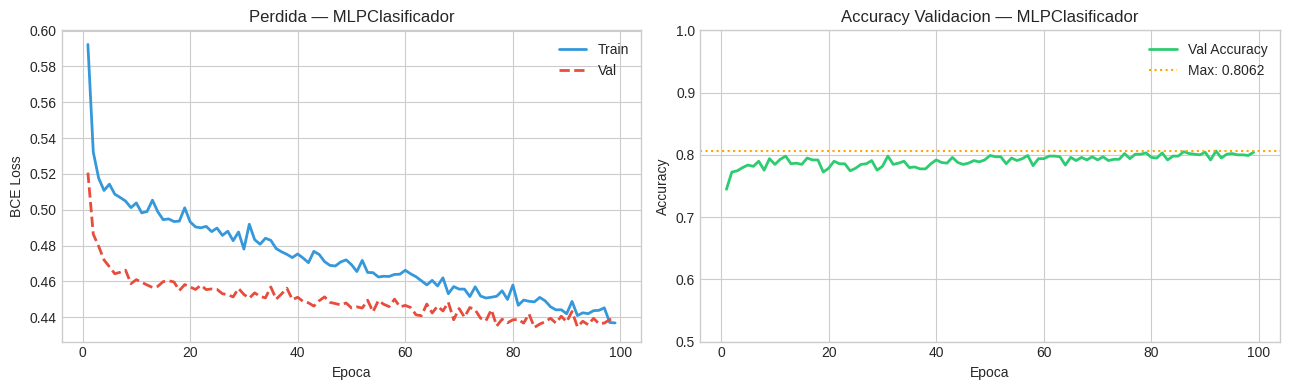

In [16]:
# Graficas de entrenamiento — clasificacion
epocas_clf = range(1, len(hist_clf["loss_train"]) + 1)
fig, axes  = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epocas_clf, hist_clf["loss_train"], label="Train", color="#3498db", lw=2)
axes[0].plot(epocas_clf, hist_clf["loss_val"],   label="Val",   color="#e74c3c", lw=2, ls="--")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("BCE Loss")
axes[0].set_title("Perdida — MLPClasificador")
axes[0].legend()

axes[1].plot(epocas_clf, hist_clf["acc_val"], color="#2ecc71", lw=2, label="Val Accuracy")
axes[1].axhline(max(hist_clf["acc_val"]), color="orange", ls=":", lw=1.5,
                label=f"Max: {max(hist_clf['acc_val']):.4f}")
axes[1].set_xlabel("Epoca")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Validacion — MLPClasificador")
axes[1].set_ylim(0.5, 1.0)
axes[1].legend()

plt.tight_layout()
plt.show()


## 2.2 Regresion con PyTorch

Arquitectura:

$$\text{Input}(11) \to \text{Linear}(64) \to \text{ReLU} \to \underbrace{\text{BatchNorm1d}(64)}_{\hat{x}=\frac{x-\mu}{\sigma+\epsilon},\; y=\gamma\hat{x}+\beta} \to \text{Linear}(32) \to \text{ReLU} \to \text{Linear}(1)$$

Sin activacion en la salida (valor continuo sin restricciones).

- **Loss**: MSE — $\mathcal{L}_{MSE} = \frac{1}{m}\sum_i(\hat{y}_i - y_i)^2$
- **Optimizer**: Adam con $\alpha = 0.001$


In [17]:
# @title Fase 2 — MLPRegresor
class MLPRegresor(nn.Module):
    """MLP para regresion del score de calidad del vino.

    Arquitectura: Linear(11->64) -> ReLU -> BatchNorm1d(64)
                  -> Linear(64->32) -> ReLU -> Linear(32->1)
    Sin activacion en la salida (prediccion continua).
    """

    def __init__(self):
        super().__init__()
        self.red = nn.Sequential(
            nn.Linear(11, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        """Propagacion hacia adelante."""
        return self.red(x)


def entrenar_regresor(modelo, train_dl, val_dl, optimizer,
                      n_epocas=150, paciencia=15, verbose=True):
    """Entrena un MLPRegresor con early stopping.

    Args:
        modelo: instancia de MLPRegresor
        train_dl, val_dl: DataLoaders
        optimizer: optimizador ya configurado (Adam, SGD, etc.)
        n_epocas: epocas maximas
        paciencia: epocas sin mejora antes de detener
        verbose: mostrar progreso
    Returns:
        dict con listas loss_train y loss_val
    """
    criterio = nn.MSELoss()

    mejor_val_loss     = float("inf")
    contador_paciencia = 0
    mejor_estado       = None

    hist    = {"loss_train": [], "loss_val": []}
    X_val_t = val_dl.dataset.X
    y_val_t = val_dl.dataset.y.unsqueeze(1)

    for epoca in range(n_epocas):
        modelo.train()
        loss_total = 0.0
        for X_b, y_b in train_dl:
            y_b = y_b.unsqueeze(1)
            optimizer.zero_grad()
            loss = criterio(modelo(X_b), y_b)
            loss.backward()
            optimizer.step()
            loss_total += loss.item()

        modelo.eval()
        with torch.no_grad():
            loss_val = criterio(modelo(X_val_t), y_val_t).item()

        hist["loss_train"].append(loss_total / len(train_dl))
        hist["loss_val"].append(loss_val)

        if loss_val < mejor_val_loss:
            mejor_val_loss     = loss_val
            contador_paciencia = 0
            mejor_estado       = {k: v.clone() for k, v in modelo.state_dict().items()}
        else:
            contador_paciencia += 1
            if contador_paciencia >= paciencia:
                if verbose:
                    print(f"  Early stopping en epoca {epoca+1}  "
                          f"(mejor val_loss={mejor_val_loss:.4f})")
                break

        if verbose and (epoca + 1) % 30 == 0:
            print(f"  Epoca {epoca+1:3d} | loss_train={hist['loss_train'][-1]:.4f} "
                  f"| loss_val={loss_val:.4f}")

    if mejor_estado:
        modelo.load_state_dict(mejor_estado)
    return hist


print("Entrenando MLPRegresor...")
reg_modelo  = MLPRegresor()
opt_reg_main = optim.Adam(reg_modelo.parameters(), lr=0.001)
hist_reg    = entrenar_regresor(reg_modelo, train_dl_reg, val_dl_reg,
                                opt_reg_main, n_epocas=150, paciencia=15)
print("Entrenamiento completado.")


Entrenando MLPRegresor...
  Epoca  30 | loss_train=0.4839 | loss_val=0.4744
  Early stopping en epoca 50  (mejor val_loss=0.4588)
Entrenamiento completado.


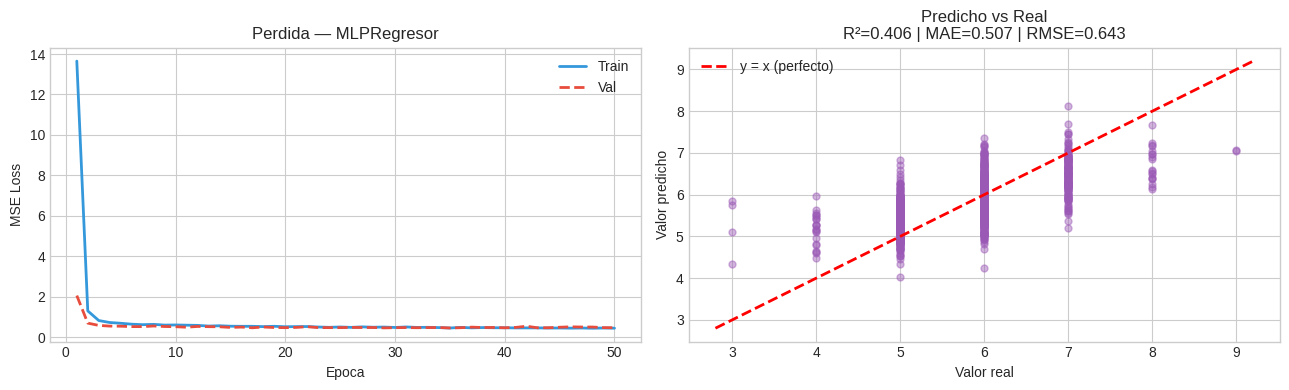

In [18]:
# Graficas de entrenamiento + scatter predicho vs real
epocas_reg = range(1, len(hist_reg["loss_train"]) + 1)
fig, axes  = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(epocas_reg, hist_reg["loss_train"], label="Train", color="#3498db", lw=2)
axes[0].plot(epocas_reg, hist_reg["loss_val"],   label="Val",   color="#e74c3c", lw=2, ls="--")
axes[0].set_xlabel("Epoca")
axes[0].set_ylabel("MSE Loss")
axes[0].set_title("Perdida — MLPRegresor")
axes[0].legend()

# Predicciones en test
reg_modelo.eval()
with torch.no_grad():
    y_pred_reg_test = reg_modelo(torch.FloatTensor(X_test_sc)).numpy().flatten()

r2_main  = r2_score(y_reg_test, y_pred_reg_test)
mae_main = mean_absolute_error(y_reg_test, y_pred_reg_test)
rmse_main = float(np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_test)))

axes[1].scatter(y_reg_test, y_pred_reg_test, alpha=0.45, color="#9b59b6", s=25)
lim = [min(y_reg_test.min(), y_pred_reg_test.min()) - 0.2,
       max(y_reg_test.max(), y_pred_reg_test.max()) + 0.2]
axes[1].plot(lim, lim, "r--", lw=2, label="y = x (perfecto)")
axes[1].set_xlabel("Valor real")
axes[1].set_ylabel("Valor predicho")
axes[1].set_title(f"Predicho vs Real\nR²={r2_main:.3f} | MAE={mae_main:.3f} | RMSE={rmse_main:.3f}")
axes[1].legend()

plt.tight_layout()
plt.show()


=== Reporte de Clasificacion — Test Set ===

              precision    recall  f1-score   support

    Malo (0)       0.71      0.68      0.70       358
   Bueno (1)       0.82      0.84      0.83       617

    accuracy                           0.78       975
   macro avg       0.77      0.76      0.76       975
weighted avg       0.78      0.78      0.78       975



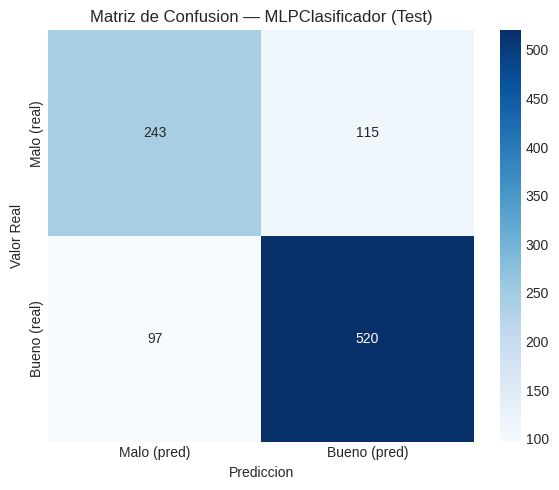

In [19]:
# @title Fase 2 — Evaluacion en Test Set
# Evaluacion completa en test — Clasificacion
clf_modelo.eval()
with torch.no_grad():
    X_test_t  = torch.FloatTensor(X_test_sc)
    probs_test = clf_modelo(X_test_t).numpy().flatten()
    preds_test = (probs_test >= 0.5).astype(int)

y_test_int = y_clf_test.astype(int)

print("=== Reporte de Clasificacion — Test Set ===\n")
print(classification_report(y_test_int, preds_test,
                             target_names=["Malo (0)", "Bueno (1)"]))

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_int, preds_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["Malo (pred)", "Bueno (pred)"],
            yticklabels=["Malo (real)", "Bueno (real)"])
ax.set_title("Matriz de Confusion — MLPClasificador (Test)")
ax.set_xlabel("Prediccion")
ax.set_ylabel("Valor Real")
plt.tight_layout()
plt.show()


In [20]:
# Evaluacion completa en test — Regresion
print("=== Metricas de Regresion — Test Set ===\n")
metricas = pd.DataFrame({
    "Metrica": ["R² (coef. determinacion)", "MAE (error absoluto medio)",
                "RMSE (raiz error cuadratico)"],
    "Valor":   [f"{r2_main:.4f}", f"{mae_main:.4f}", f"{rmse_main:.4f}"],
    "Interpretacion": [
        f"{r2_main:.1%} de varianza explicada",
        f"Error promedio +/-{mae_main:.3f} puntos",
        f"Desviacion tipica del error: {rmse_main:.3f} puntos",
    ],
})
display(metricas.set_index("Metrica"))


=== Metricas de Regresion — Test Set ===



,Valor,Interpretacion
Metrica,,
R² (coef. determinacion),0.4056,40.6% de varianza explicada
MAE (error absoluto medio),0.5068,Error promedio +/-0.507 puntos
RMSE (raiz error cuadratico),0.6429,Desviacion tipica del error: 0.643 puntos


---
# FASE 3 — Mejoras y Comparacion

## Objetivo Pedagogico

Comparamos sistematicamente el efecto de distintas decisiones de diseno:

### 3.1 Regularizacion
Previene el **sobreajuste (overfitting)** penalizando modelos demasiado complejos:

| Tecnica | Mecanismo |
|---------|-----------|
| Sin regularizacion | Referencia base |
| **Dropout($p$)** | Desactiva neuronas aleatoriamente durante train |
| **L2 / Weight Decay** | $\mathcal{L}_{total} = \mathcal{L}_{BCE} + \lambda \|W\|_2^2$ |

### 3.2 Optimizadores

| Optimizador | Actualizacion |
|-------------|---------------|
| SGD + momentum | $v_t = \beta v_{t-1} + \nabla\mathcal{L},\; W \leftarrow W - \alpha v_t$ |
| Adam | Combina momentum ($\beta_1$) y RMSprop ($\beta_2$) |
| RMSprop | $W \leftarrow W - \frac{\alpha}{\sqrt{\mathbb{E}[g^2] + \epsilon}} g$ |


Entrenando sin regularizacion...
Entrenando con Dropout(0.4)...
Entrenando con L2 (weight_decay=1e-4)...
Entrenamiento completado.



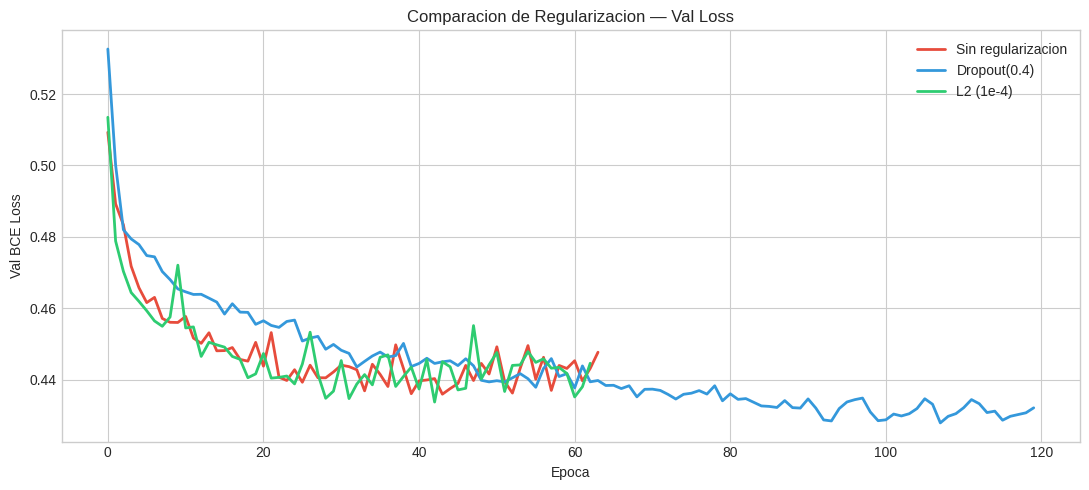

In [21]:
# @title Fase 3 — Comparacion de Regularizacion
# Comparacion de regularizacion (clasificacion)
N_EPOCAS_REG  = 120
PACIENCIA_REG = 20

print("Entrenando sin regularizacion...")
clf_sin_reg = MLPClasificador(p_dropout=0.0)
hist_sin_reg = entrenar_clasificador(clf_sin_reg, train_dl_clf, val_dl_clf,
                                     n_epocas=N_EPOCAS_REG, paciencia=PACIENCIA_REG,
                                     verbose=False)

print("Entrenando con Dropout(0.4)...")
clf_dropout = MLPClasificador(p_dropout=0.4)
hist_dropout = entrenar_clasificador(clf_dropout, train_dl_clf, val_dl_clf,
                                     n_epocas=N_EPOCAS_REG, paciencia=PACIENCIA_REG,
                                     verbose=False)

print("Entrenando con L2 (weight_decay=1e-4)...")
clf_l2 = MLPClasificador(p_dropout=0.0)
hist_l2 = entrenar_clasificador(clf_l2, train_dl_clf, val_dl_clf,
                                n_epocas=N_EPOCAS_REG, paciencia=PACIENCIA_REG,
                                peso_decay=1e-4, verbose=False)

print("Entrenamiento completado.\n")

# Plot comparativo
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(hist_sin_reg["loss_val"], label="Sin regularizacion", color="#e74c3c", lw=2)
ax.plot(hist_dropout["loss_val"], label="Dropout(0.4)",       color="#3498db", lw=2)
ax.plot(hist_l2["loss_val"],      label="L2 (1e-4)",          color="#2ecc71", lw=2)
ax.set_xlabel("Epoca")
ax.set_ylabel("Val BCE Loss")
ax.set_title("Comparacion de Regularizacion — Val Loss")
ax.legend()
plt.tight_layout()
plt.show()


In [22]:
# Tabla comparativa de regularizacion
def acc_test_clf(modelo):
    """Accuracy en test para un clasificador."""
    modelo.eval()
    with torch.no_grad():
        pred = (modelo(torch.FloatTensor(X_test_sc)) >= 0.5).float().numpy().flatten()
    return float(np.mean(pred == y_clf_test))

acc_sin  = acc_test_clf(clf_sin_reg)
acc_drop = acc_test_clf(clf_dropout)
acc_l2v  = acc_test_clf(clf_l2)

tabla_reg = pd.DataFrame({
    "Modelo": ["Sin regularizacion", "Dropout(0.4)", "L2 (weight_decay=1e-4)"],
    "Mejor Val Loss":     [f"{min(hist_sin_reg['loss_val']):.4f}",
                           f"{min(hist_dropout['loss_val']):.4f}",
                           f"{min(hist_l2['loss_val']):.4f}"],
    "Test Accuracy":      [f"{acc_sin:.4f}", f"{acc_drop:.4f}", f"{acc_l2v:.4f}"],
    "Epocas entrenadas":  [len(hist_sin_reg["loss_val"]),
                           len(hist_dropout["loss_val"]),
                           len(hist_l2["loss_val"])],
})
print("=== Tabla Comparativa — Regularizacion ===")
display(tabla_reg)


=== Tabla Comparativa — Regularizacion ===


,Modelo,Mejor Val Loss,Test Accuracy,Epocas entrenadas
0,Sin regularizacion,0.4359,0.7651,64
1,Dropout(0.4),0.4279,0.7867,120
2,L2 (weight_decay=1e-4),0.4337,0.7785,63


Entrenando con SGD + momentum...
Entrenando con Adam...
Entrenando con RMSprop...
Comparacion completada.



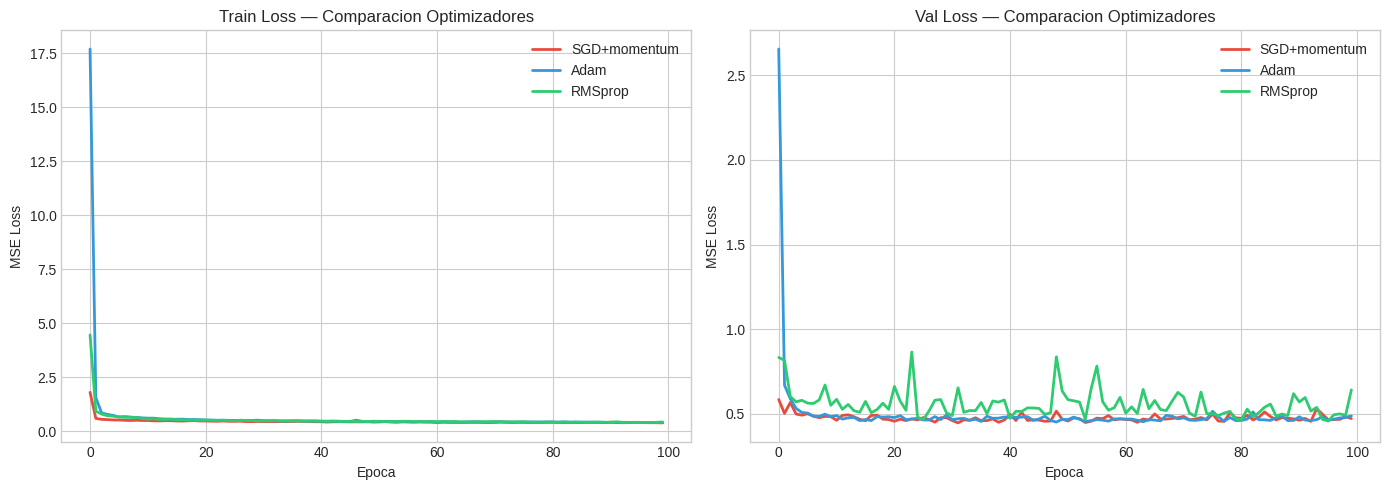

In [23]:
# @title Fase 3 — Comparacion de Optimizadores
# Comparacion de optimizadores (regresion, 100 epocas fijas)
N_EPOCAS_OPT = 100

print("Entrenando con SGD + momentum...")
reg_sgd = MLPRegresor()
hist_sgd = entrenar_regresor(reg_sgd, train_dl_reg, val_dl_reg,
                              optim.SGD(reg_sgd.parameters(), lr=0.01, momentum=0.9),
                              n_epocas=N_EPOCAS_OPT, paciencia=N_EPOCAS_OPT, verbose=False)

print("Entrenando con Adam...")
reg_adam = MLPRegresor()
hist_adam_cmp = entrenar_regresor(reg_adam, train_dl_reg, val_dl_reg,
                                   optim.Adam(reg_adam.parameters(), lr=0.001),
                                   n_epocas=N_EPOCAS_OPT, paciencia=N_EPOCAS_OPT, verbose=False)

print("Entrenando con RMSprop...")
reg_rms = MLPRegresor()
hist_rms = entrenar_regresor(reg_rms, train_dl_reg, val_dl_reg,
                              optim.RMSprop(reg_rms.parameters(), lr=0.001),
                              n_epocas=N_EPOCAS_OPT, paciencia=N_EPOCAS_OPT, verbose=False)

print("Comparacion completada.\n")

# Plot convergencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colores  = {"SGD+momentum": "#e74c3c", "Adam": "#3498db", "RMSprop": "#2ecc71"}
historiales = {
    "SGD+momentum": hist_sgd,
    "Adam":         hist_adam_cmp,
    "RMSprop":      hist_rms,
}

for nombre, hist in historiales.items():
    axes[0].plot(hist["loss_train"], label=nombre, color=colores[nombre], lw=2)
    axes[1].plot(hist["loss_val"],   label=nombre, color=colores[nombre], lw=2)

for ax, titulo in zip(axes, ["Train Loss", "Val Loss"]):
    ax.set_xlabel("Epoca")
    ax.set_ylabel("MSE Loss")
    ax.set_title(f"{titulo} — Comparacion Optimizadores")
    ax.legend()

plt.tight_layout()
plt.show()


In [24]:
# Metricas finales de los optimizadores
def metricas_reg_test(modelo):
    """R², MAE, RMSE en test set para un regresor."""
    modelo.eval()
    with torch.no_grad():
        pred = modelo(torch.FloatTensor(X_test_sc)).numpy().flatten()
    return (r2_score(y_reg_test, pred),
            mean_absolute_error(y_reg_test, pred),
            float(np.sqrt(mean_squared_error(y_reg_test, pred))))

r2_s, mae_s, rmse_s = metricas_reg_test(reg_sgd)
r2_a, mae_a, rmse_a = metricas_reg_test(reg_adam)
r2_r, mae_r, rmse_r = metricas_reg_test(reg_rms)

tabla_opt = pd.DataFrame({
    "Optimizador": ["SGD+momentum(0.9)", "Adam(lr=0.001)", "RMSprop(lr=0.001)"],
    "Val Loss Final": [f"{hist_sgd['loss_val'][-1]:.4f}",
                       f"{hist_adam_cmp['loss_val'][-1]:.4f}",
                       f"{hist_rms['loss_val'][-1]:.4f}"],
    "R²":   [f"{r2_s:.4f}", f"{r2_a:.4f}", f"{r2_r:.4f}"],
    "MAE":  [f"{mae_s:.4f}", f"{mae_a:.4f}", f"{mae_r:.4f}"],
    "RMSE": [f"{rmse_s:.4f}", f"{rmse_a:.4f}", f"{rmse_r:.4f}"],
})
print("=== Tabla Comparativa — Optimizadores (Regresion) ===")
display(tabla_opt)


=== Tabla Comparativa — Optimizadores (Regresion) ===


,Optimizador,Val Loss Final,R²,MAE,RMSE
0,SGD+momentum(0.9),0.4711,0.4132,0.4928,0.6388
1,Adam(lr=0.001),0.4870,0.4114,0.4998,0.6398
2,RMSprop(lr=0.001),0.6409,0.3984,0.5006,0.6468


---
# Resumen Ejecutivo

## Tabla Comparativa Global

| Fase | Modelo | Tarea | Regularizacion | Optimizador | Metrica |
|------|--------|-------|----------------|-------------|---------|
| 1 | MLPNumpy | Clasificacion | Ninguna | SGD lr=0.05 | Accuracy |
| 2 | MLPClasificador | Clasificacion | Dropout(0.3) | Adam lr=0.001 | Accuracy + F1 |
| 2 | MLPRegresor | Regresion | BatchNorm | Adam lr=0.001 | R², MAE, RMSE |
| 3 | MLPClasificador x3 | Clasificacion | Sin/Dropout/L2 | Adam lr=0.001 | Accuracy |
| 3 | MLPRegresor x3 | Regresion | BatchNorm | SGD/Adam/RMSprop | R², RMSE |

## Conclusiones

### Clasificacion
- **El Dropout** reduce el sobreajuste al forzar representaciones distribuidas;
  suele superar al modelo sin regularizacion en test cuando hay overfitting evidente.
- **L2 (weight decay)** produce una curva de val_loss mas suave y monotona que Dropout,
  util cuando el dataset es pequeno o el modelo converge con oscilaciones.

### Regresion
- **Adam** converge mas rapido y con mayor estabilidad que SGD y RMSprop en
  las primeras 20–30 epocas, gracias al ajuste adaptativo de la tasa de aprendizaje.
- **RMSprop** alcanza rendimiento similar a Adam en datasets de tamano medio.
- **SGD + momentum** puede competir pero requiere mas epocas y mayor ajuste del lr.

### Lecciones Clave
1. La **normalizacion** (StandardScaler) es critica: sin ella el entrenamiento es inestable.
2. El **early stopping** previene el overfitting sin necesidad de fijar el numero exacto de epocas.
3. La **inicializacion Xavier** garantiza flujo de gradientes desde el inicio.
4. Las **curvas train vs val** revelan inmediatamente overfitting, underfitting o problemas de convergencia.
5. **Adam** es un punto de partida robusto para la mayoria de problemas tabulares.

### Proximos Pasos
- Arquitecturas mas profundas con residual connections.
- Learning Rate Scheduling (ReduceLROnPlateau, CosineAnnealing).
- Busqueda automatica de hiperparametros con Optuna.
- Ensemble de clasificadores para mayor robustez.
